In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [28]:
data = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [29]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
data.shape

(7043, 21)

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Dicionário de dados

| # | Variável | Descrição |
|---|---|---|
| 1 | `customerID` | Identificador único do cliente. |
| 2 | `gender` | Gênero do cliente. |
| 3 | `SeniorCitizen` | Indica se o cliente é idoso. |
| 4 | `Partner` | Indica se o cliente possui parceiro. |
| 5 | `Dependents` | Indica se o cliente possui dependentes. |
| 6 | `tenure` | Tempo de permanência do cliente, em meses. |
| 7 | `PhoneService` | Indica se o cliente possui serviço telefônico. |
| 8 | `MultipleLines` | Indica se o cliente possui múltiplas linhas. |
| 9 | `InternetService` | Tipo de serviço de internet contratado. |
| 10 | `OnlineSecurity` | Indica se o cliente possui segurança online. |
| 11 | `OnlineBackup` | Indica se o cliente possui backup online. |
| 12 | `DeviceProtection` | Indica se o cliente possui proteção de dispositivo. |
| 13 | `TechSupport` | Indica se o cliente possui suporte técnico. |
| 14 | `StreamingTV` | Indica se o cliente possui serviço de streaming de TV. |
| 15 | `StreamingMovies` | Indica se o cliente possui serviço de streaming de filmes. |
| 16 | `Contract` | Tipo de contrato do cliente. |
| 17 | `PaperlessBilling` | Indica se o cliente utiliza cobrança sem papel. |
| 18 | `PaymentMethod` | Método de pagamento utilizado. |
| 19 | `MonthlyCharges` | Valor cobrado mensalmente. |
| 20 | `TotalCharges` | Valor total cobrado durante o relacionamento. |
| 21 | `Churn` | Indica se o cliente cancelou o serviço. |

In [32]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [33]:
data['TotalCharges'].isnull().sum()
linhas_data_nulos = data.loc[data['TotalCharges'].isnull()]
linhas_data_nulos

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [34]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)

Os 11 valores ausentes em TotalCharges pertencem a clientes com tenure = 0. Como ainda não houve tempo de permanência para acumular cobranças, os valores foram substituídos por zero.

In [35]:
data['customerID'].nunique() == len(data)

True

In [36]:
data.duplicated().sum()

np.int64(0)

In [37]:
# data.describe(include='str')
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Variável-alvo

In [38]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [39]:
data['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

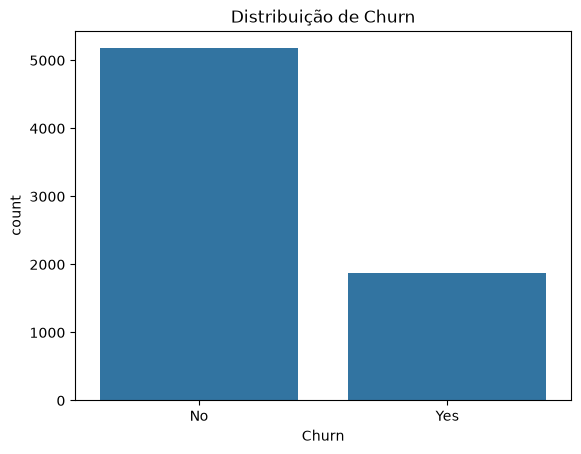

In [40]:
sns.countplot(data=data, x='Churn')
plt.title('Distribuição de Churn')
plt.show()

A taxa de churn é de 26,54%, indicando um desbalanceamento moderado da variável-alvo.

### Separação das variáveis por tipo

In [41]:
numeric_cols = data.select_dtypes('number')
categorical_cols = data.select_dtypes('string')


In [42]:
categorical_cols = categorical_cols.drop('customerID', axis=1)

### Análise das variáveis numéricas

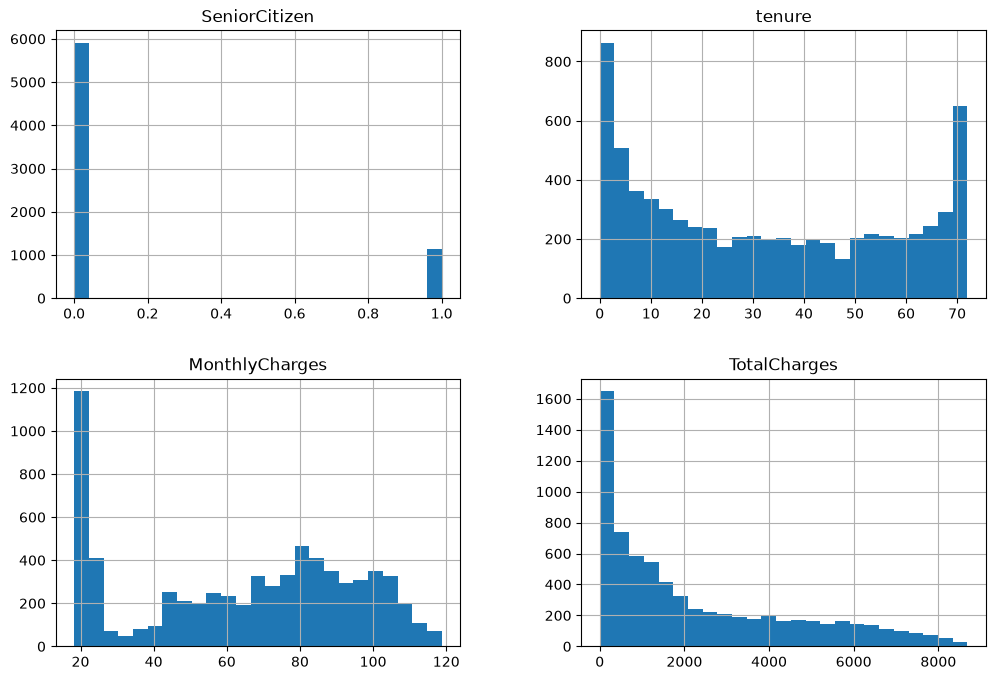

In [43]:
numeric_cols.hist(bins=25, figsize=(12,8))
plt.show()

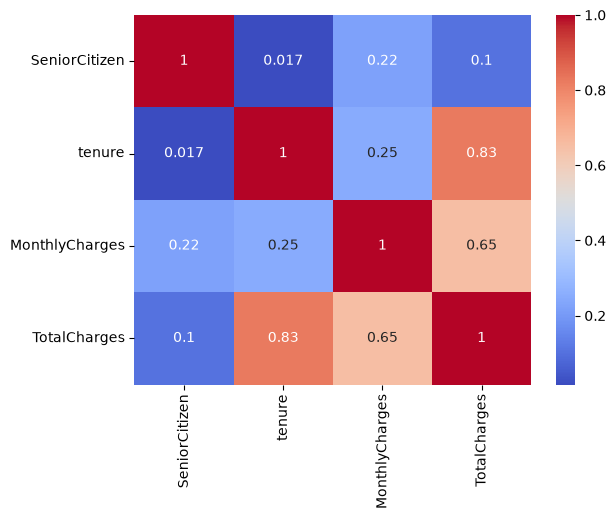

In [44]:
corr = numeric_cols.corr()
sns.heatmap(data=corr,cmap='coolwarm', annot=True)
plt.show()

### Análise das variáveis categóricas

In [45]:
for col in categorical_cols.columns:
    print(f"\n--- {col} ---")
    print(data[col].value_counts())
    print(data[col].value_counts(normalize=True) * 100)


--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Partner
No     51.69672
Yes    48.30328
Name: proportion, dtype: float64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
Dependents
No     70.041176
Yes    29.958824
Name: proportion, dtype: float64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
PhoneService
Yes    90.316626
No      9.683374
Name: proportion, dtype: float64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
MultipleLines
No                  48.132898
Yes                 42.183729
No phone service     9.683374
Name: proportion, dtype: float64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             

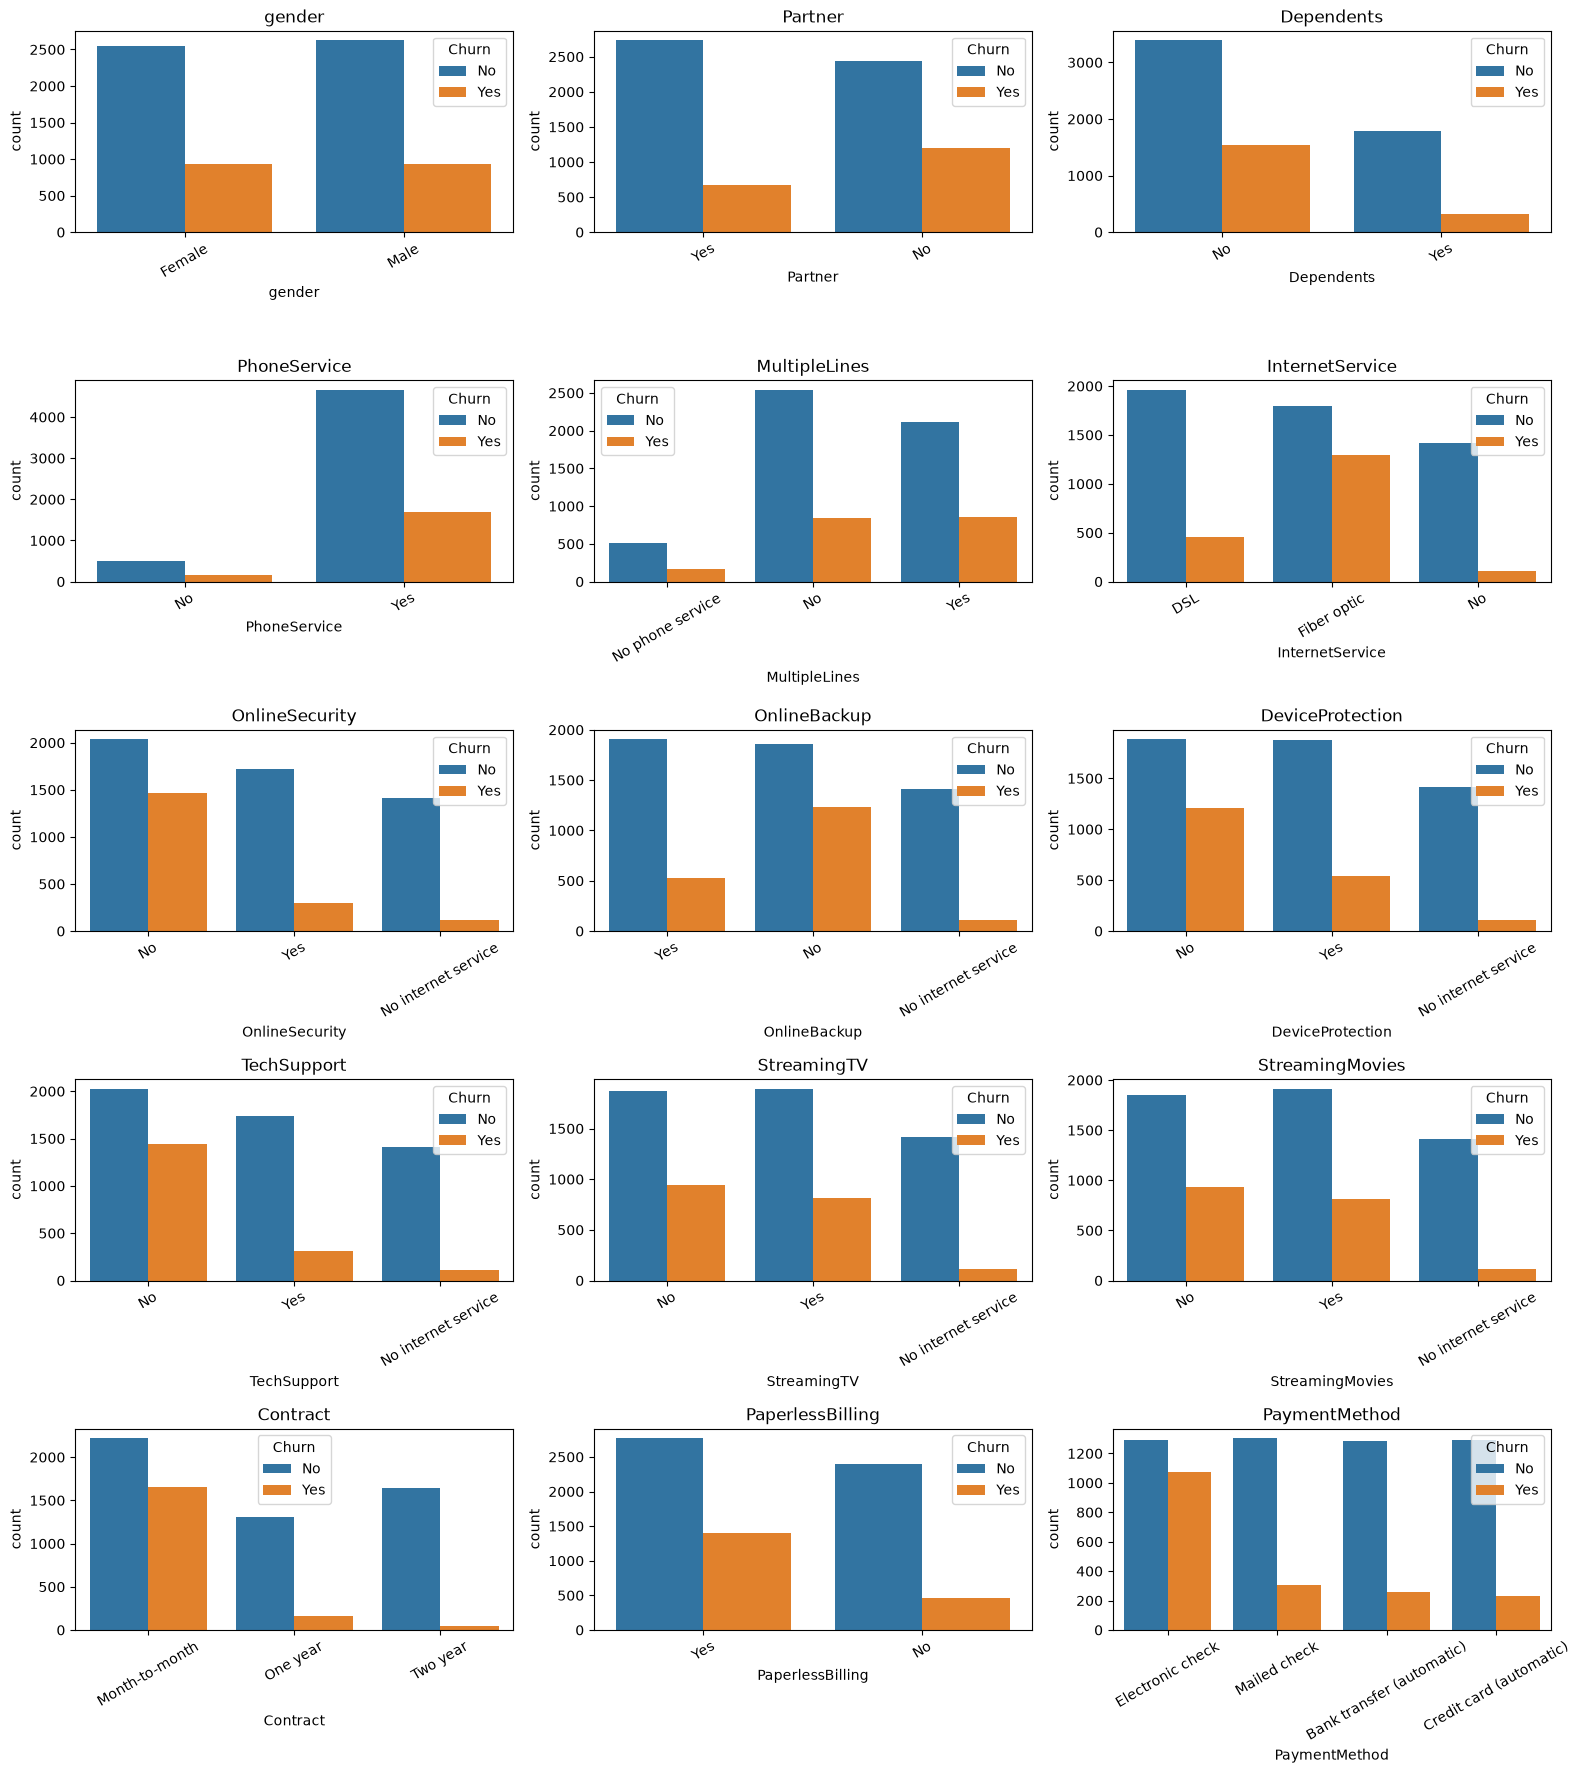

In [46]:
colunas = categorical_cols.drop(columns="Churn").columns

plt.figure(figsize=(16, 20))

for i, coluna in enumerate(colunas):
    plt.subplot(6, 3, i + 1)
    sns.countplot(data=data, x=coluna, hue='Churn')
    plt.title(coluna)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

A relação entre o total pago e o tempo de permanência pode ser examinada em um gráfico de dispersão, com destaque para a ocorrência de churn.

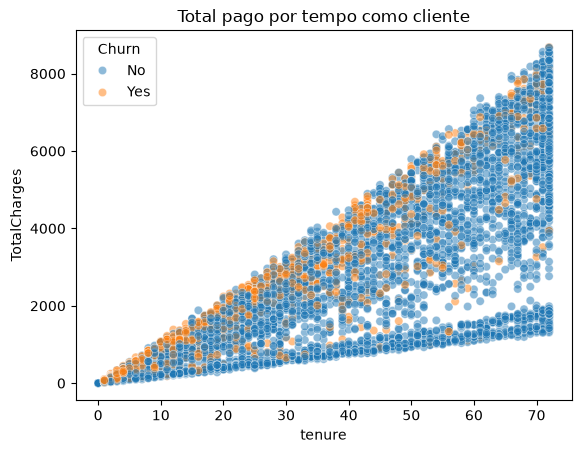

In [47]:
sns.scatterplot(
    data=data,
    x='tenure',
    y='TotalCharges',
    hue='Churn',
    alpha=0.5
)
plt.title('Total pago por tempo como cliente')
plt.show()

Como esperado, `TotalCharges` cresce com `tenure`. Para tempos de permanência semelhantes, valores acumulados maiores parecem estar associados ao churn, possivelmente por refletirem mensalidades mais altas. Essa relação é apenas associativa.

In [48]:
data.groupby('Churn')['tenure'].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

A mediana do tempo de permanência é de 10 meses entre clientes que cancelaram e de 38 meses entre os que permaneceram.

In [49]:
data.groupby('Churn')['MonthlyCharges'].median()

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

In [65]:

data.groupby(['Contract', 'PaymentMethod'])['Churn'].agg(
    clientes = 'size',
    cancelamentos = lambda x: (x=='Yes').sum(),
    taxa_churn=lambda x: (x == 'Yes').mean() * 100
).sort_values('taxa_churn',ascending=False)

clientes  cancelamentos  taxa_churn
Contract       PaymentMethod                                                 
Month-to-month Electronic check               1850            994   53.729730
               Bank transfer (automatic)       589            201   34.125637
               Credit card (automatic)         543            178   32.780847
               Mailed check                    893            282   31.578947
One year       Electronic check                347             64   18.443804
               Credit card (automatic)         398             41   10.301508
               Bank transfer (automatic)       391             38    9.718670
Two year       Electronic check                168             13    7.738095
One year       Mailed check                    337             23    6.824926
Two year       Bank transfer (automatic)       564             19    3.368794
               Credit card (automatic)         581             13    2.237522
               Mailed check                    382              3    0.785340

In [66]:
resumo = (
    data.groupby(['Contract', 'InternetService'])['Churn']
    .agg(
        clientes='size',
        cancelamentos=lambda x: (x == 'Yes').sum(),
        taxa_churn=lambda x: (x == 'Yes').mean() * 100
    )
    .sort_values('taxa_churn', ascending=False)
)

resumo

clientes  cancelamentos  taxa_churn
Contract       InternetService                                     
Month-to-month Fiber optic          2128           1162   54.605263
               DSL                  1223            394   32.215863
One year       Fiber optic           539            104   19.294991
Month-to-month No                    524             99   18.893130
One year       DSL                   570             53    9.298246
Two year       Fiber optic           429             31    7.226107
One year       No                    364              9    2.472527
Two year       DSL                   628             12    1.910828
               No                    638              5    0.783699

## Principais conclusões

1. A taxa de churn é de **26,54%**, indicando um desbalanceamento moderado da variável-alvo.

2. Clientes que cancelaram apresentam menor tempo de permanência e mensalidades mais altas: a mediana de `tenure` é de **10 meses** entre clientes com churn e **38 meses** entre os demais; para `MonthlyCharges`, as medianas são **79,65** e **64,43**, respectivamente.

3. As maiores taxas de churn estão associadas a contratos mensais, pagamento por cheque eletrônico e internet por fibra óptica. O segmento com contrato mensal e fibra óptica apresentou churn de **54,60%**, enquanto contrato mensal e cheque eletrônico apresentou **53,73%**.

4. Clientes sem segurança online, suporte técnico, backup ou proteção de dispositivo também apresentaram maior churn. Em contraste, gênero, serviço telefônico, múltiplas linhas e serviços de streaming mostraram pouca associação individual.

5. Os resultados sugerem que clientes novos, com contrato mensal, mensalidade elevada e determinados serviços ou formas de pagamento merecem maior atenção em estratégias de retenção. Entretanto, essas relações são associativas e ainda precisam ser avaliadas durante a modelagem.